# HAH913E – Activité physique 

## Physical-actvity-assignment-00

Lien : [GitHub repository](https://github.com/sarah-mussotte/Physical-activity-00-Project)

## Membres de l'équipe :

- Faraj Tania
- Mussotte Sarah
- Vigneau-Sugar Thomas

Le travail à été réparti entre chaque membre de l'équipe. Chacun a fait un notebook sur une EPOCH. Ceci est le fichier final avec les 3 EPOCH mais vous pouvez voir en détail ce que chacun a fait dans le [GitHub repository](https://github.com/sarah-mussotte/Physical-activity-00-Project) commun. 

## Bibliothèque

Nous commençons par importer les bibliothèques nécessaires à l'analyse.

- numpy permet d'effectuer les calculs numériques
- pandas permet de charger et manipuler les données du fichier CSV
- matplotlib permet de représenter graphiquement les résultats

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Chargement des données

Le fichier "0_z.csv" contient les données brutes enregistrées avec un accéléromètre Axivity AX3 porté au poignet non dominant.

Le fichier contient quatre colonnes :

- t : le temps en secondes 
- x : l'accélération selon l'axe x, en g 
- y : l'accélération selon l'axe y, en g 
- z : l'accélération selon l'axe z, en g

Nous utilisons une fonction pour charger les données afin de structurer le code et de pouvoir réutiliser facilement cette étape.

In [ ]:
def load_data(path):
    """Charge les données brutes de l'accéléromètre."""
    return pd.read_csv(path, comment="#")


data = load_data("0_z.csv")

data.head()

,t,x,y,z
0,0.00,-0.0938,-0.0156,0.9531
1,0.02,-0.0938,-0.0156,0.9531
2,0.04,-0.0938,-0.0156,0.9531
3,0.06,-0.0938,-0.0156,0.9531
4,0.08,-0.0938,-0.0156,0.9531


## 2. Calcul de l'ENMO

L'ENMO (*Euclidean Norm Minus One*) permet de combiner les accélérations mesurées selon les trois axes en une seule valeur.

On calcule d'abord la norme euclidienne du vecteur d'accélération :

$$
\sqrt{x^2+y^2+z^2}
$$

Puis on soustrait 1 g, qui correspond à l'accélération due à la gravité :

$$
ENMO = \sqrt{x^2+y^2+z^2}-1
$$

Lorsque l'accéléromètre est quasiment immobile, il ne mesure que la gravité : la norme vaut environ 1 g et l'ENMO environ 0. Soustraire 1 g permet donc d'enlever la gravité et de garder seulement la partie du signal due au mouvement. On peut donc avoir des valeurs négatives.

In [ ]:
def calculate_enmo(df):
    """Calcule l'ENMO à partir des trois axes x, y et z."""
    df = df.copy()

    df["enmo"] = (
        np.sqrt(
            df["x"]**2 +
            df["y"]**2 +
            df["z"]**2
        ) - 1
    )

    return df


data = calculate_enmo(data)

data.head()

,t,x,y,z,enmo
0,0.00,-0.0938,-0.0156,0.9531,-0.042168
1,0.02,-0.0938,-0.0156,0.9531,-0.042168
2,0.04,-0.0938,-0.0156,0.9531,-0.042168
3,0.06,-0.0938,-0.0156,0.9531,-0.042168
4,0.08,-0.0938,-0.0156,0.9531,-0.042168


## 3. Détermination de la fréquence d'échantillonnage

Avant d'intégrer l'ENMO sur différentes époques, nous devons déterminer la fréquence d'échantillonnage du signal.

La fréquence d'échantillonnage correspond au nombre de mesures enregistrées chaque seconde.

Elle est calculée à partir de l'écart de temps entre deux mesures successives :

$$
f_s = \frac{1}{t_{i+1}-t_i}
$$

Dans notre jeu de données, deux mesures successives sont espacées de 0,02 seconde. La fréquence d'échantillonnage est donc de 50 Hz, ce qui signifie que l'accéléromètre enregistre 50 mesures par seconde.

In [ ]:
fs = 1 / (data["t"].iloc[1] - data["t"].iloc[0])

print("Fréquence d'échantillonnage :", fs, "Hz")

Fréquence d'échantillonnage : 50.0 Hz


## 4. Intégration de l'ENMO sur différentes époques

Nous souhaitons maintenant regrouper les valeurs d'ENMO dans des intervalles de temps appelés « époques » (*epochs*).

La consigne demande d'étudier trois durées :

- 10 secondes ;
- 30 secondes ;
- 60 secondes.

Le nombre d'échantillons contenu dans une époque est calculé avec :

$$
N = epoch \times f_s
$$

Avec une fréquence de 50 Hz :

- une époque de 10 secondes contient 500 échantillons ;
- une époque de 30 secondes contient 1500 échantillons ;
- une époque de 60 secondes contient 3000 échantillons.

Pour chaque époque, les valeurs d'ENMO sont additionnées puis multipliées par la durée de l'époque exprimée en minutes afin d'obtenir une valeur d'ENMO intégré en g.min.

Nous créons une fonction afin de pouvoir appliquer la même méthode aux trois durées.

In [ ]:
def integrate_enmo(df, epoch_seconds, fs):
    """Intègre l'ENMO sur des époques de durée donnée."""

    samples_per_epoch = int(epoch_seconds * fs)
    n_epochs = len(df) // samples_per_epoch

    integrated = []
    start_times = []

    for i in range(n_epochs):
        start = i * samples_per_epoch
        end = start + samples_per_epoch

        epoch = df["enmo"].iloc[start:end]

        integrated_value = np.sum(epoch) * (epoch_seconds / 60)

        integrated.append(integrated_value)
        start_times.append(df["t"].iloc[start])

    return pd.DataFrame({
        "start": start_times,
        "integrated_enmo": integrated
    })

## 5. Vérification du nombre d'échantillons par époque

Nous vérifions que le nombre d'échantillons obtenu pour chaque durée correspond bien à la fréquence d'échantillonnage de 50 Hz.

Cette vérification permet de s'assurer que le découpage du signal est correct avant de calculer les valeurs intégrées.

In [ ]:
for epoch in [10, 30, 60]:
    samples = int(epoch * fs)

    print(
        f"Époque de {epoch} s : "
        f"{samples} échantillons"
    )

Époque de 10 s : 500 échantillons
Époque de 30 s : 1500 échantillons
Époque de 60 s : 3000 échantillons


## 6. Calcul de l'ENMO intégré pour 10, 30 et 60 secondes

Nous appliquons maintenant la fonction "integrate_enmo" aux trois durées demandées dans la consigne.

Les résultats sont stockés dans trois tableaux différents afin de pouvoir vérifier les valeurs obtenues pour chaque durée.

In [ ]:
epochs_10 = integrate_enmo(data, 10, fs)
epochs_30 = integrate_enmo(data, 30, fs)
epochs_60 = integrate_enmo(data, 60, fs)

In [ ]:
print("Époques de 10 secondes :")
display(epochs_10.head())

print("Époques de 30 secondes :")
display(epochs_30.head())

print("Époques de 60 secondes :")
display(epochs_60.head())

Époques de 10 secondes :


,start,integrated_enmo
0,0.0,-3.779849
1,10.0,-3.760051
2,20.0,-3.770097
3,30.0,-3.759663
4,40.0,-3.839059


Époques de 30 secondes :


,start,integrated_enmo
0,0.0,-33.929990
1,30.0,-34.063278
2,60.0,-33.845530
3,90.0,-33.919386
4,120.0,-33.807162


Époques de 60 secondes :


,start,integrated_enmo
0,0.0,-135.986535
1,60.0,-135.529833
2,120.0,-134.928962
3,180.0,-135.749533
4,240.0,976.726915


## 7. Représentation graphique

Nous créons maintenant une fonction permettant de représenter l'ENMO intégré et le signal ENMO brut.

La figure est composée de deux graphiques :

- en haut, les valeurs d'ENMO intégré sont représentées sous forme de barres ;
- en bas, le signal ENMO brut est représenté en fonction du temps.

Les deux graphiques partagent le même axe temporel afin de faciliter la comparaison entre le signal original et les valeurs intégrées.

La largeur des barres correspond à la durée de l'époque considérée.

Cette fonction permet de produire facilement les trois graphiques demandés dans la consigne.

In [ ]:
def plot_enmo_epoch(df, epoch_seconds, fs):
    """Trace l'ENMO intégré et le signal ENMO brut."""

    epochs = integrate_enmo(df, epoch_seconds, fs)

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        sharex=True,
        figsize=(10, 6)
    )

    # ENMO intégré
    epoch_times = epochs["start"] / 60
    epoch_width = epoch_seconds / 60

    ax1.bar(
        epoch_times,
        epochs["integrated_enmo"],
        width=epoch_width * 0.9,
        align="edge",
        alpha=0.7
    )

    ax1.set_title(
        f"ENMO intégré sur des intervalles de {epoch_seconds} s"
    )
    ax1.set_ylabel("ENMO intégré (g.min)")

    # ENMO brut
    ax2.plot(
        df["t"] / 60,
        df["enmo"],
        alpha=0.5
    )

    ax2.set_title("ENMO au cours du temps")
    ax2.set_xlabel("Temps (minutes)")
    ax2.set_ylabel("ENMO (g)")

    plt.tight_layout()
    plt.show()

#### ENMO intégré sur EPOCH 10s

Nous commençons par représenter l'ENMO intégré sur des époques de 10 secondes.

Une durée d'époque courte permet de conserver davantage de détails temporels sur les variations de l'activité.

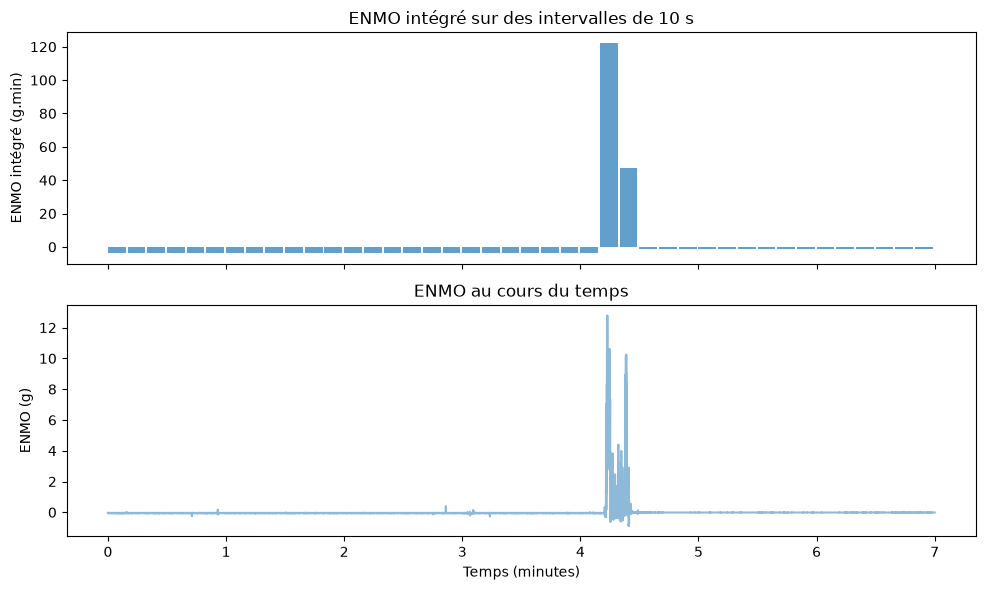

In [ ]:
plot_enmo_epoch(data, 10, fs)

### ENMO intégré sur EPOCH 30s

Nous appliquons maintenant la même fonction pour des époques de 30 secondes.

Une durée plus longue regroupe davantage de mesures dans chaque barre et fournit donc une représentation plus agrégée de l'activité.

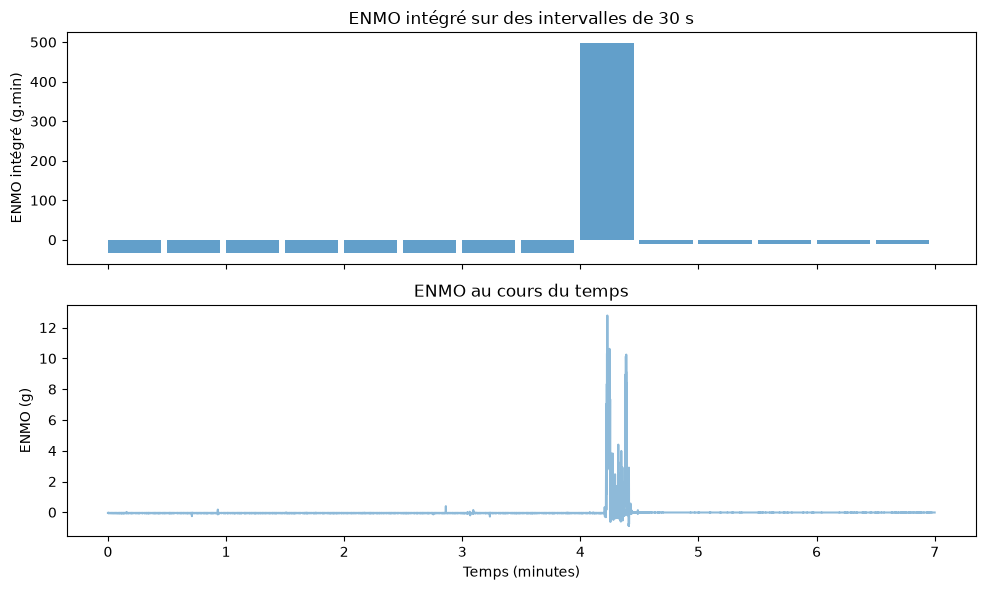

In [ ]:
plot_enmo_epoch(data, 30, fs)

#### ENMO intégré sur EPOCH 60s

Enfin, nous représentons l'ENMO intégré sur des époques de 60 secondes.

Les données sont regroupées sur des intervalles d'une minute, ce qui produit moins de barres et donne une représentation plus synthétique de l'activité enregistrée.

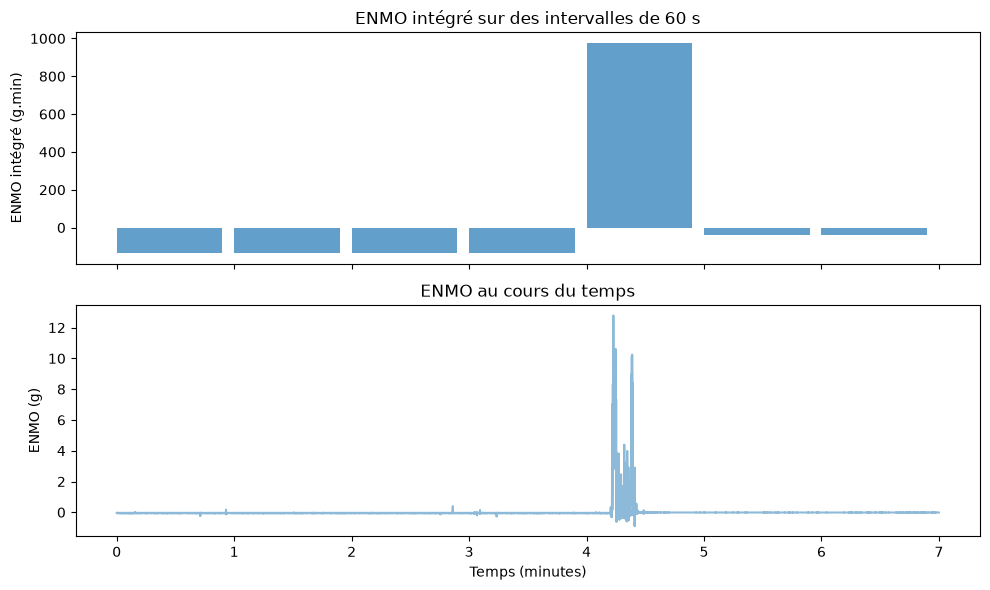

In [ ]:
plot_enmo_epoch(data, 60, fs)

## 8. Assistance par IA et utilisation de Copilot

AI tools were used by each member of the team during the development of their respective part. The generated suggestions were reviewed and adapted before being included in the final notebook.

### A. Tania Faraj (10s epoch)

| Prompt utilisé | Suggestion obtenue | Ce que j'ai modifié après relecture |
|---|---|---|
| Write a Python function that computes ENMO from x, y, z columns of a pandas dataframe | Copilot a repéré que le notebook contenait déjà une fonction `compute_enmo` et a proposé presque le même code : norme de (x, y, z) moins 1, sur une copie du dataframe (variable `result` au lieu de `df`). | Rien : sa proposition était équivalente à mon code, j'ai gardé ma version. |
| Write a function that integrates ENMO over 10 second epochs | Copilot a vu que les mesures sont espacées de 0,02 s (50 Hz) et a proposé une nouvelle fonction qui multiplie la somme de l'ENMO de chaque epoch par cet intervalle (et non par la durée de l'epoch), en disant que mon multiplicateur surestimait l'intégrale. Il l'a ajoutée dans une nouvelle cellule et a voulu l'exécuter. | J'ai refusé l'exécution et annulé sa cellule (Undo). Sa méthode donne des valeurs 500 fois plus petites (environ 0,25 au lieu de 122 g.min pour le pic), qui ne correspondent pas aux graphiques de référence de la consigne. J'ai donc gardé ma fonction `integrate_enmo` pour obtenir les mêmes graphiques que ceux demandés. |
##### Utilisation de Claude (Anthropic)

J'ai utilisé Claude pour m'aider à écrire le code du notebook, puis je lui ai posé des questions pour comprendre les choix faits dans chaque fonction.

| Prompt utilisé | Réponse obtenue | Ce que j'ai vérifié ou retenu |
|---|---|---|
| Dans `compute_enmo`, pourquoi faire `df.copy()` avant d'ajouter la colonne `enmo`, au lieu de modifier directement le dataframe ? | `copy()` évite de modifier le dataframe d'origine : la fonction renvoie un nouveau tableau sans effet de bord. | J'ai gardé `copy()` : on peut relancer les cellules sans modifier les données de départ. |
| Dans `integrate_enmo`, que fait exactement `(df["t"] // epoch).astype(int)`, et pourquoi utiliser `groupby` plutôt qu'une boucle `for` ? | La division entière donne le numéro d'epoch de chaque mesure (ex. `23.4 // 10 = 2`) ; `groupby` fait toutes les sommes d'un coup, sans gérer les bornes à la main. | J'ai vérifié avec `data.groupby((data["t"] // 10).astype(int)).size()` que chaque epoch de 10 s contient bien 500 mesures (50 Hz × 10 s). |
| Dans `plot_enmo`, à quoi sert `sharex=True`, et pourquoi décale-t-on les barres de `width / 2` ? | `sharex=True` aligne les deux graphiques sur le même axe du temps ; `ax.bar()` centre les barres, donc on décale d'une demi-largeur pour que chaque barre couvre son epoch. | J'ai vérifié sur mon graphique que la barre du pic est bien alignée avec le mouvement visible sur la courbe du bas, vers 4 min. |

### B. Thomas Vigneau-Sugar (30s epoch)

AI assistance was used to clarify the main methodological steps of the analysis. The generated suggestions were reviewed before being included in the notebook.

### Prompt 1
"What is the formula for ENMO using tri-axial accelerometer data x, y, and z?"

**Review and modification:**  
The suggested ENMO formula was checked and retained for the calculation used in this notebook.

### Prompt 2
"What does it mean to integrate ENMO over an epoch?"

**Review and modification:**  
The proposed approach was compared with the reference plots provided in the assignment and adapted for the 30-second epoch used in my contribution.

### Prompt 3
"Should negative ENMO values be set to zero?"

**Review and modification:**  
Truncating negative ENMO values to zero was considered and tested. This option was not retained because it did not reproduce the reference plot provided in the assignment.



### C.  Sarah Mussotte (60s epoch)

L'assistance par IA a été utilisée pour clarifier les principales étapes méthodologiques de l'analyse. Les suggestions obtenues ont été vérifiées puis adaptées avant d'être intégrées au notebook.

### Prompt 1

**« Quelle est la fréquence d'échantillonnage de données d'accéléromètre lorsque deux mesures successives sont espacées de 0,02 seconde ? »**

**Vérification et modification :**

Le calcul proposé a été vérifié et utilisé pour déterminer la fréquence d'échantillonnage du jeu de données. Le résultat obtenu est de 50 Hz, ce qui signifie que 50 mesures sont enregistrées chaque seconde.

### Prompt 2

**« Comment intégrer l'ENMO sur des epochs de 60 secondes lorsque la fréquence d'échantillonnage est de 50 Hz ? »**

**Vérification et modification :**

La méthode proposée a été vérifiée puis adaptée à la structure de notre notebook. J'ai vérifié qu'une epoch de 60 secondes contient 3000 échantillons à 50 Hz. L'intégration a ensuite été calculée pour chaque epoch de 60 secondes.

### Prompt 3

**« Comment représenter graphiquement l'ENMO intégré sur des epochs de 60 secondes avec le signal ENMO brut ? »**

**Vérification et modification :**

La méthode de représentation proposée a été adaptée afin de correspondre aux graphiques de référence fournis dans la consigne. Les valeurs d'ENMO intégré sont représentées sous forme de barres dans le graphique supérieur, tandis que le signal ENMO brut est représenté dans le graphique inférieur. Les deux graphiques partagent le même axe temporel afin de faciliter la comparaison.

